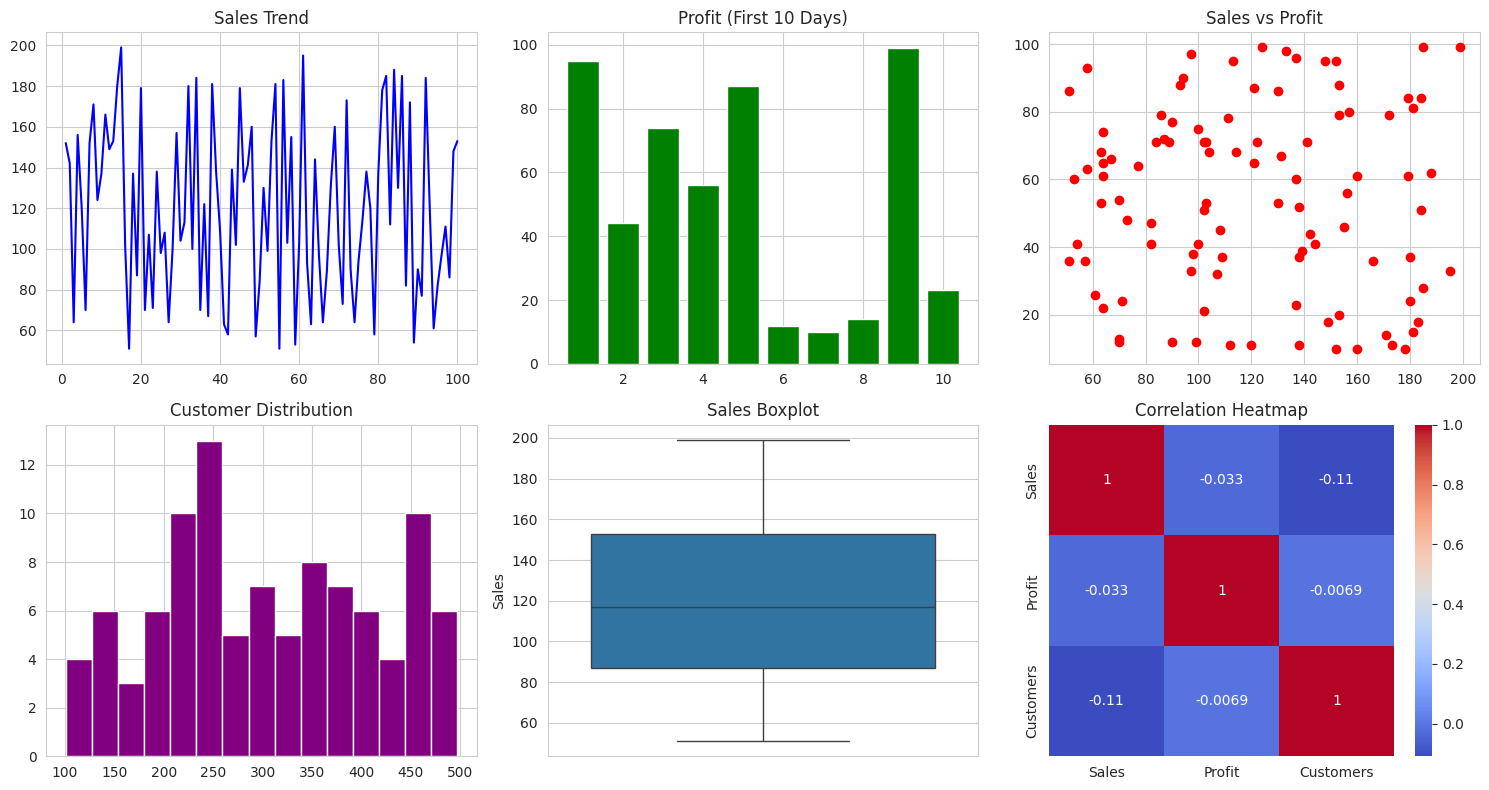

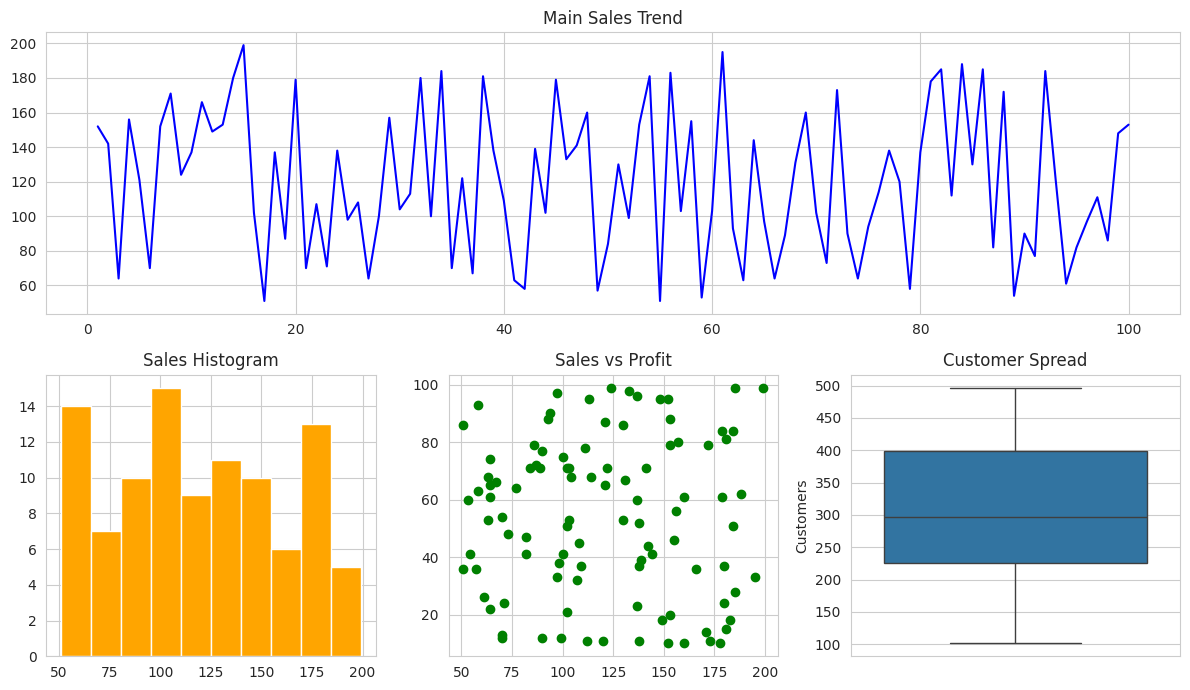

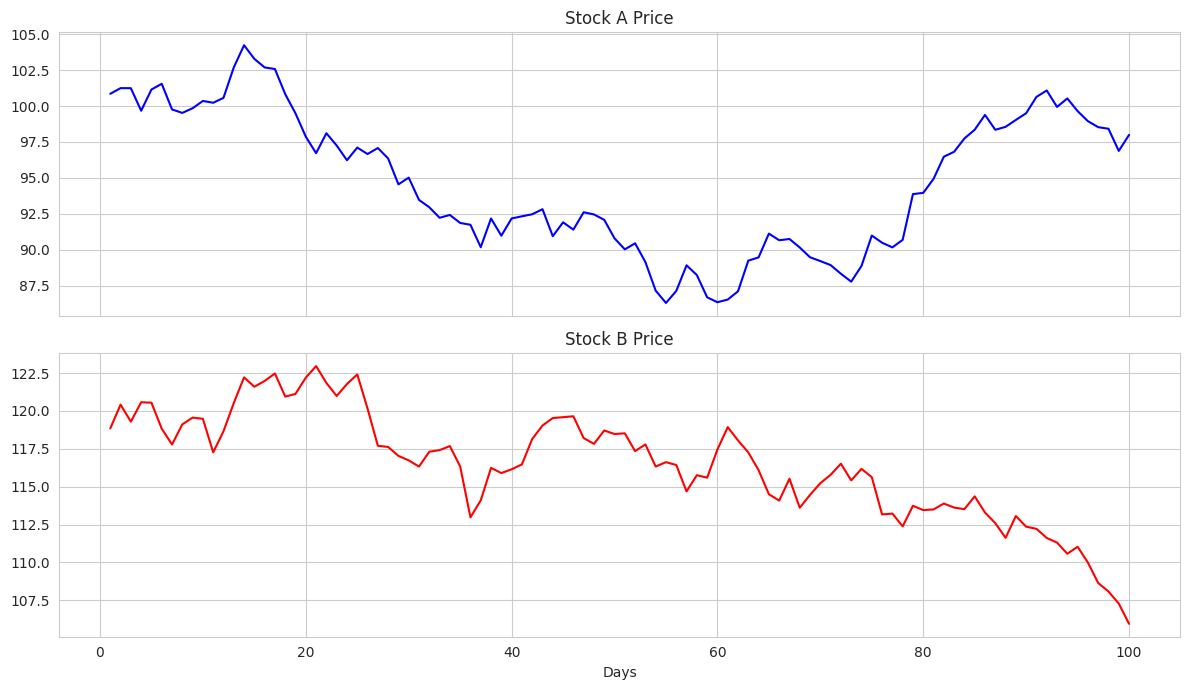

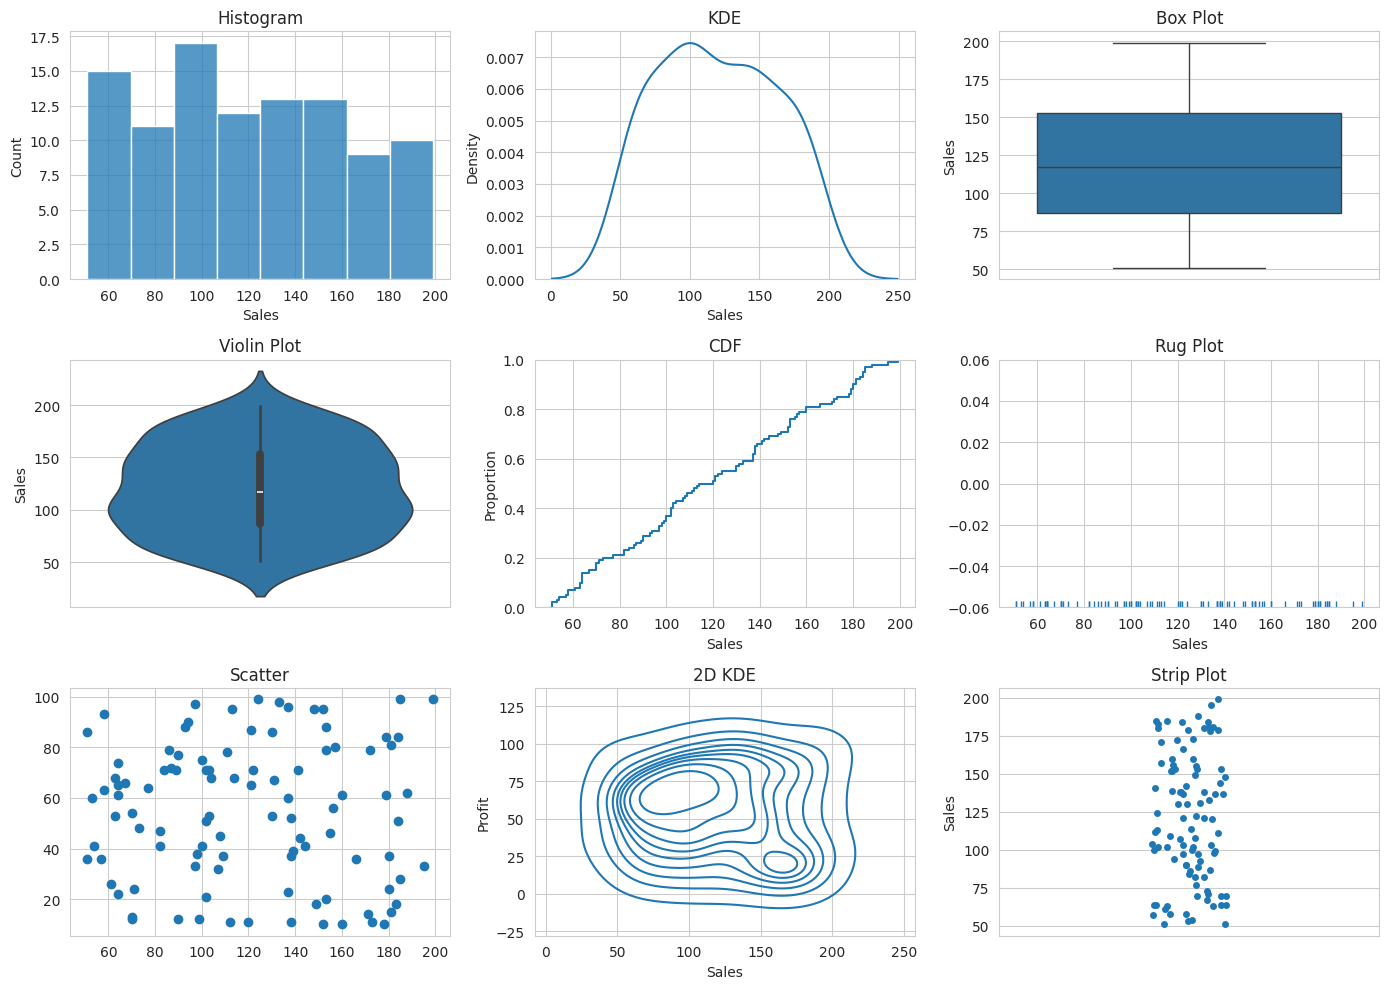

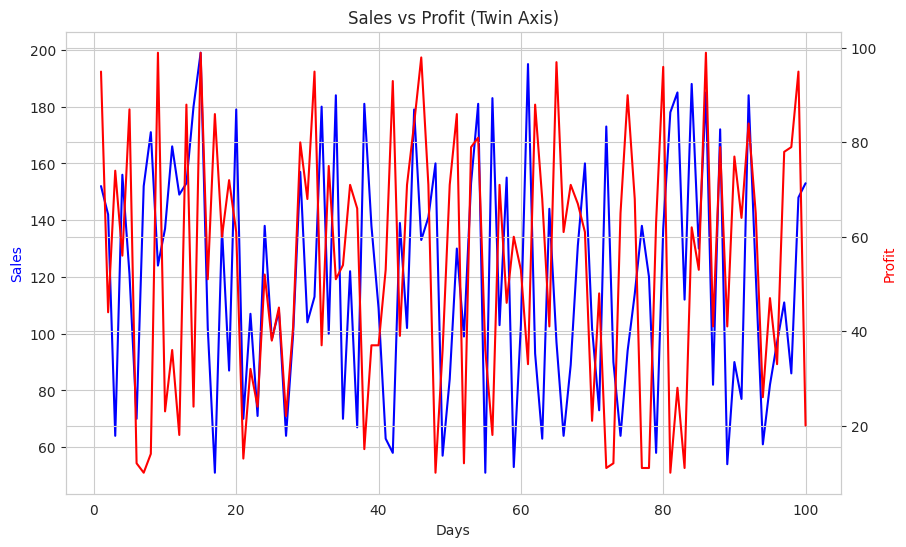

In [1]:

# Advanced Visualization with Subplots
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)

# Sample Dataset
data = pd.DataFrame({
    "Day": np.arange(1,101),
    "Sales": np.random.randint(50,200,100),
    "Profit": np.random.randint(10,100,100),
    "Customers": np.random.randint(100,500,100),
    "Stock_A": np.cumsum(np.random.normal(0,1,100)) + 100,
    "Stock_B": np.cumsum(np.random.normal(0,1,100)) + 120
})

# 1. 2×3 GRID DASHBOARD (plt.subplots)
fig, axes = plt.subplots(2,3, figsize=(15,8))

# Line Plot
axes[0,0].plot(data["Day"], data["Sales"], color="blue")
axes[0,0].set_title("Sales Trend")

# Bar Plot
axes[0,1].bar(data["Day"][:10], data["Profit"][:10], color="green")
axes[0,1].set_title("Profit (First 10 Days)")

# Scatter Plot
axes[0,2].scatter(data["Sales"], data["Profit"], color="red")
axes[0,2].set_title("Sales vs Profit")

# Histogram
axes[1,0].hist(data["Customers"], bins=15, color="purple")
axes[1,0].set_title("Customer Distribution")

# Box Plot
sns.boxplot(y=data["Sales"], ax=axes[1,1])
axes[1,1].set_title("Sales Boxplot")

# Heatmap
corr = data[["Sales","Profit","Customers"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# 2. GRIDSPEC LAYOUT (Unequal Sized Subplots)
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12,7))
gs = GridSpec(2,3)

ax1 = fig.add_subplot(gs[0,:])      # top full width
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[1,2])

ax1.plot(data["Day"], data["Sales"], color="blue")
ax1.set_title("Main Sales Trend")

ax2.hist(data["Sales"], color="orange")
ax2.set_title("Sales Histogram")

ax3.scatter(data["Sales"], data["Profit"], color="green")
ax3.set_title("Sales vs Profit")

sns.boxplot(y=data["Customers"], ax=ax4)
ax4.set_title("Customer Spread")

plt.tight_layout()
plt.show()

# 3. SHARED X-AXIS (Stock Price Analysis)
fig, (ax1, ax2) = plt.subplots(2,1, sharex=True, figsize=(12,7))

ax1.plot(data["Day"], data["Stock_A"], color="blue")
ax1.set_title("Stock A Price")

ax2.plot(data["Day"], data["Stock_B"], color="red")
ax2.set_title("Stock B Price")

plt.xlabel("Days")
plt.tight_layout()
plt.show()

# 4. 3×3 DISTRIBUTION ANALYSIS
fig, axes = plt.subplots(3,3, figsize=(14,10))

# Histogram
sns.histplot(data["Sales"], ax=axes[0,0])
axes[0,0].set_title("Histogram")

# KDE
sns.kdeplot(data["Sales"], ax=axes[0,1])
axes[0,1].set_title("KDE")

# Boxplot
sns.boxplot(y=data["Sales"], ax=axes[0,2])
axes[0,2].set_title("Box Plot")

# Violin
sns.violinplot(y=data["Sales"], ax=axes[1,0])
axes[1,0].set_title("Violin Plot")

# ECDF (CDF)
sns.ecdfplot(data["Sales"], ax=axes[1,1])
axes[1,1].set_title("CDF")

# Rug Plot
sns.rugplot(data["Sales"], ax=axes[1,2])
axes[1,2].set_title("Rug Plot")

# Scatter
axes[2,0].scatter(data["Sales"], data["Profit"])
axes[2,0].set_title("Scatter")

# Joint KDE
sns.kdeplot(x=data["Sales"], y=data["Profit"], ax=axes[2,1])
axes[2,1].set_title("2D KDE")

# Strip plot
sns.stripplot(y=data["Sales"], ax=axes[2,2])
axes[2,2].set_title("Strip Plot")

plt.tight_layout()
plt.show()

# 5. TWIN / SECONDARY AXES (twinx)
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(data["Day"], data["Sales"], color="blue", label="Sales")
ax1.set_xlabel("Days")
ax1.set_ylabel("Sales", color="blue")

ax2 = ax1.twinx()
ax2.plot(data["Day"], data["Profit"], color="red", label="Profit")
ax2.set_ylabel("Profit", color="red")

plt.title("Sales vs Profit (Twin Axis)")
plt.show()